Supply Chain and Sourcing Strategy: Bayesian Decision Support Model

The business problem modeled:
Activated carbon manufacturing depends on domestic coal, coconut imports, customer demand, and spent carbon returns.
Tariffs, weather, supply disruptions, and feedstock shortages introduce uncertainty.
Managers need to estimate business stability and select the better sourcing strategy (Domestic vs Import Heavy) under changing conditions.

This program provides:
Bayes Rule example for updating tariff severity beliefs
Bayesian Network “digital twin” of the supply chain
Scenario analysis to compute the best sourcing strategy

1. 
Bayes’ Rule is used to update the probability of severe tariffs occurring after receiving a market signal. This demonstrates how new evidence can shift prior beliefs, allowing leaders to adjust sourcing decisions and risk mitigation plans based on updated probabilities.

In [5]:
#1: Imports, Bayes' Rule, and BN Core
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any
import pandas as pd
import matplotlib.pyplot as plt

#This function demonstrates how you update a belief (prior probability) after recieving new evidence (market signal).
def bayes_posterior(prior: float, sensitivity: float, specificity: float) -> float:

#Compute P(Severe Signal+) using Bayes' Rule.
    #prior       = P(Severe) before the signal
    #sensitivity = P(Signal+, Severe)
    #specificity = P(Signal-, Not Severe)
    
    p_severe = prior
    p_not_severe = 1.0 - p_severe

    p_pos_given_severe = sensitivity
    p_pos_given_not_severe = 1.0 - specificity  #false positive rate

    numerator = p_pos_given_severe * p_severe
    denominator = numerator + p_pos_given_not_severe * p_not_severe

    return numerator / denominator


def run_bayes_demo() -> None:
#Run a simple Bayes' Rule demo for tariff risk.
    prior = 0.25          #25% chance of severe tariffs before signal
    sensitivity = 0.85    #P(signal+, severe)
    specificity = 0.80    #P(signal-, not severe)

    posterior = bayes_posterior(prior, sensitivity, specificity)
    
    print("*" * 60)
    print("Part 1: Bayes' Rule Demo")
    print("*" * 60)
    print(f"Prior P(Severe): {prior:.2%}")
    print(f"Sensitivity:     {sensitivity:.2%}")
    print(f"Specificity:     {specificity:.2%}")
    print(f"Posterior P(Severe | Signal+): {posterior:.2%}")


#Bayesian Network Core
@dataclass
class Variable:
    name: str
    domain: List[Any]
    parents: List[str]
    cpt: Dict[Tuple[Tuple[str, Any], ...], Dict[Any, float]]

class BayesianNetwork:
    def __init__(self, variables: List[Variable]):
        self.vars: Dict[str, Variable] = {v.name: v for v in variables}
        self.order: List[str] = self.topological_order()

    def topological_order(self) -> List[str]: #Simple topological sort: parents always come before children. Raises if there's a cycle.

        remaining = set(self.vars.keys())
        order: List[str] = []

        while remaining:
            progressed = False
            for var in list(remaining):
                parent_set = set(self.vars[var].parents)
                if parent_set.issubset(order):
                    order.append(var)
                    remaining.remove(var)
                    progressed = True
            if not progressed:
                raise ValueError("Cycle or invalid parents in Bayesian Network.")
        return order

    def prob_of(self, var: str, value: Any, event: Dict[str, Any]) -> float: #Return P(var = value | parents in event).
        node = self.vars[var]
        key = tuple(sorted((p, event[p]) for p in node.parents))
        return node.cpt[key][value]


def enumeration_ask(query_var: str, evidence: Dict[str, Any], bn: BayesianNetwork) -> Dict[Any, float]: #Compute P(query_var | evidence) using full enumeration. Returns a normalized probability distribution.
    
    def enumerate_all(vars_left: List[str], ev: Dict[str, Any]) -> float:
        if not vars_left:
            return 1.0
        Y = vars_left[0]
        rest = vars_left[1:]

        if Y in ev:
            return bn.prob_of(Y, ev[Y], ev) * enumerate_all(rest, ev)

        total = 0.0
        for y in bn.vars[Y].domain:
            ev2 = dict(ev)
            ev2[Y] = y
            total += bn.prob_of(Y, y, ev2) * enumerate_all(rest, ev2)
        return total

    #initialize distribution
    dist: Dict[Any, float] = {val: 0.0 for val in bn.vars[query_var].domain}
    vars_to_enum = [v for v in bn.order if v not in evidence]

    for val in bn.vars[query_var].domain:
        ev2 = dict(evidence)
        ev2[query_var] = val
        dist[val] = enumerate_all(vars_to_enum, ev2)

    total = sum(dist.values())
    return {k: v / total for k, v in dist.items()}


def prior_cpt(p: Dict[Any, float]) -> Dict[Tuple[Tuple[str, Any], ...], Dict[Any, float]]: #Utility for root-node CPTs (no parents) 
    return {tuple(): p}

2. 
A Bayesian Network was constructed to represent uncertainty across global supply, domestic coal availability, customer demand, feedstock sufficiency, cost pressure, and production outcomes. This structure forms a probabilistic digital twin of the supply chain, enabling scenario analysis and strategic recommendations.

In [6]:
#2 Build BN
def build_bn() -> BayesianNetwork:
    #Root nodes
    MotherNatureRisk = Variable(
        "MotherNatureRisk",
        ["Low", "High"],
        [],
        prior_cpt({"Low": 0.7, "High": 0.3})
    )

    TariffImpact = Variable(
        "TariffImpact",
        ["None", "Severe"],
        [],
        prior_cpt({"None": 0.6, "Severe": 0.4})
    )

    CustomerDemand = Variable(
        "CustomerDemand",
        ["Low", "High"],
        [],
        prior_cpt({"Low": 0.4, "High": 0.6})
    )

    #CoconutImports, MotherNatureRisk
    CoconutImports = Variable(
        "CoconutImports",
        ["Stable", "Disrupted"],
        ["MotherNatureRisk"],
        {
            tuple(sorted((("MotherNatureRisk", "Low"),))): {"Stable": 0.8, "Disrupted": 0.2},
            tuple(sorted((("MotherNatureRisk", "High"),))): {"Stable": 0.4, "Disrupted": 0.6},
        }
    )

    #DomesticCoalSupply, MotherNatureRisk
    DomesticCoalSupply = Variable(
        "DomesticCoalSupply",
        ["High", "Low"],
        ["MotherNatureRisk"],
        {
            tuple(sorted((("MotherNatureRisk", "Low"),))): {"High": 0.7, "Low": 0.3},
            tuple(sorted((("MotherNatureRisk", "High"),))): {"High": 0.3, "Low": 0.7},
        }
    )

    #FeedstockSufficiency, DomesticCoalSupply, CustomerDemand
    fs_cpt: Dict[Tuple[Tuple[str, Any], ...], Dict[Any, float]] = {}
    for dc in ["High", "Low"]:
        for dem in ["Low", "High"]:
            key = tuple(sorted((("DomesticCoalSupply", dc), ("CustomerDemand", dem))))
            if dc == "High" and dem == "Low":
                fs_cpt[key] = {"Yes": 0.95, "No": 0.05}
            elif dc == "High" and dem == "High":
                fs_cpt[key] = {"Yes": 0.80, "No": 0.20}
            elif dc == "Low" and dem == "Low":
                fs_cpt[key] = {"Yes": 0.60, "No": 0.40}
            else:
                fs_cpt[key] = {"Yes": 0.30, "No": 0.70}

    FeedstockSufficiency = Variable(
        "FeedstockSufficiency",
        ["Yes", "No"],
        ["DomesticCoalSupply", "CustomerDemand"],
        fs_cpt
    )

    #CostPressure, TariffImpact, CoconutImports
    cp_cpt: Dict[Tuple[Tuple[str, Any], ...], Dict[Any, float]] = {}
    for ti in ["None", "Severe"]:
        for ci in ["Stable", "Disrupted"]:
            key = tuple(sorted((("TariffImpact", ti), ("CoconutImports", ci))))
            if ti == "Severe" or ci == "Disrupted":
                cp_cpt[key] = {"Low": 0.20, "High": 0.80}
            else:
                cp_cpt[key] = {"Low": 0.70, "High": 0.30}

    CostPressure = Variable(
        "CostPressure",
        ["Low", "High"],
        ["TariffImpact", "CoconutImports"],
        cp_cpt
    )

    #ProductionTargetMet, FeedstockSufficiency
    ProductionTargetMet = Variable(
        "ProductionTargetMet",
        ["Yes", "No"],
        ["FeedstockSufficiency"],
        {
            tuple(sorted((("FeedstockSufficiency", "Yes"),))): {"Yes": 0.90, "No": 0.10},
            tuple(sorted((("FeedstockSufficiency", "No"),))): {"Yes": 0.20, "No": 0.80},
        }
    )

    #BusinessStabilityIndex, ProductionTargetMet, CostPressure
    bsi_cpt: Dict[Tuple[Tuple[str, Any], ...], Dict[Any, float]] = {}
    for pt in ["Yes", "No"]:
        for cp in ["Low", "High"]:
            key = tuple(sorted((("ProductionTargetMet", pt), ("CostPressure", cp))))
            if pt == "Yes" and cp == "Low":
                bsi_cpt[key] = {"Stable": 0.90, "HighRisk": 0.10}
            elif pt == "Yes" and cp == "High":
                bsi_cpt[key] = {"Stable": 0.60, "HighRisk": 0.40}
            elif pt == "No" and cp == "Low":
                bsi_cpt[key] = {"Stable": 0.40, "HighRisk": 0.60}
            else:
                bsi_cpt[key] = {"Stable": 0.10, "HighRisk": 0.90}

    BusinessStabilityIndex = Variable(
        "BusinessStabilityIndex",
        ["Stable", "HighRisk"],
        ["ProductionTargetMet", "CostPressure"],
        bsi_cpt
    )

    #SourcingStrategy, CostPressure, CoconutImports
    ss_cpt: Dict[Tuple[Tuple[str, Any], ...], Dict[Any, float]] = {}
    for cp in ["Low", "High"]:
        for ci in ["Stable", "Disrupted"]:
            key = tuple(sorted((("CostPressure", cp), ("CoconutImports", ci))))
            if cp == "High" or ci == "Disrupted":
                ss_cpt[key] = {"Domestic": 0.70, "ImportHeavy": 0.30}
            else:
                ss_cpt[key] = {"Domestic": 0.30, "ImportHeavy": 0.70}

    SourcingStrategy = Variable(
        "SourcingStrategy",
        ["Domestic", "ImportHeavy"],
        ["CostPressure", "CoconutImports"],
        ss_cpt
    )

    bn = BayesianNetwork([
        MotherNatureRisk,
        TariffImpact,
        CustomerDemand,
        CoconutImports,
        DomesticCoalSupply,
        FeedstockSufficiency,
        CostPressure,
        ProductionTargetMet,
        BusinessStabilityIndex,
        SourcingStrategy
    ])

    return bn

3.
The program evaluates several real-world scenarios: severe tariffs, high natural risk, favorable conditions, and demand shocks. For each scenario, the Bayesian Network outputs:
The probability of business stability versus high risk
The likelihood of each sourcing strategy (Domestic vs Import Heavy)
A recommended sourcing strategy based on highest probability

These results translate risk into actionable guidance, supporting better decision making under uncertainty.

In [7]:
#3: Scenario Runner, runs four realistic business scenarios
def run_scenarios(bn: BayesianNetwork) -> List[Dict[str, Any]]:
    
    #Run multiple what-if scenarios, print results, and return a list of dicts for DataFrame/charting.
    results: List[Dict[str, Any]] = []

    def scenario(name: str, evidence: Dict[str, Any]) -> None:
        bsi = enumeration_ask("BusinessStabilityIndex", evidence, bn)
        ss = enumeration_ask("SourcingStrategy", evidence, bn)
        recommended = max(ss, key=ss.get)

        #Print for the notebook
        print(f"Scenario: {name}")
        print(" Evidence:", evidence)
        print(" P(BusinessStabilityIndex):", bsi)
        print(" P(SourcingStrategy):", ss)
        print(f" Recommended: {recommended}")
        print("*" * 60)

        #Store numeric values for charts
        results.append({
            "Scenario": name,
            "Stable": round(float(bsi["Stable"]), 2),
            "HighRisk": round(float(bsi["HighRisk"]), 2),
            "Domestic": round(float(ss["Domestic"]), 2),
            "ImportHeavy": round(float(ss["ImportHeavy"]), 2),
            "Recommended": recommended
        })

    scenario("Base (No Evidence)", {})
    scenario("Severe Tariffs", {"TariffImpact": "Severe"})
    scenario("High Risk Weather", {"MotherNatureRisk": "High"})
    scenario("Worst Case", {"TariffImpact": "Severe", "MotherNatureRisk": "High"})
    scenario("Best Case", {
        "TariffImpact": "None",
        "MotherNatureRisk": "Low",
        "CustomerDemand": "High"
    })

    return results

************************************************************
Part 1: Bayes' Rule Demo
************************************************************
Prior P(Severe): 25.00%
Sensitivity:     85.00%
Specificity:     80.00%
Posterior P(Severe | Signal+): 58.62%
Scenario: Base (No Evidence)
 Evidence: {}
 P(BusinessStabilityIndex): {'Stable': 0.55752, 'HighRisk': 0.44248}
 P(SourcingStrategy): {'Domestic': 0.564, 'ImportHeavy': 0.43600000000000005}
 Recommended: Domestic
************************************************************
Scenario: Severe Tariffs
 Evidence: {'TariffImpact': 'Severe'}
 P(BusinessStabilityIndex): {'Stable': 0.49632, 'HighRisk': 0.50368}
 P(SourcingStrategy): {'Domestic': 0.6456, 'ImportHeavy': 0.3544000000000001}
 Recommended: Domestic
************************************************************
Scenario: High Risk Weather
 Evidence: {'MotherNatureRisk': 'High'}
 P(BusinessStabilityIndex): {'Stable': 0.4892000000000001, 'HighRisk': 0.5108}
 P(SourcingStrategy): {'Dome

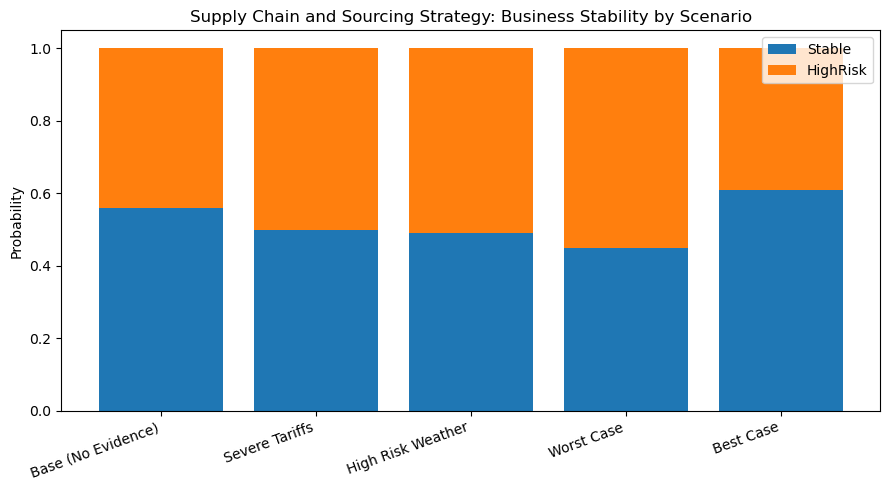

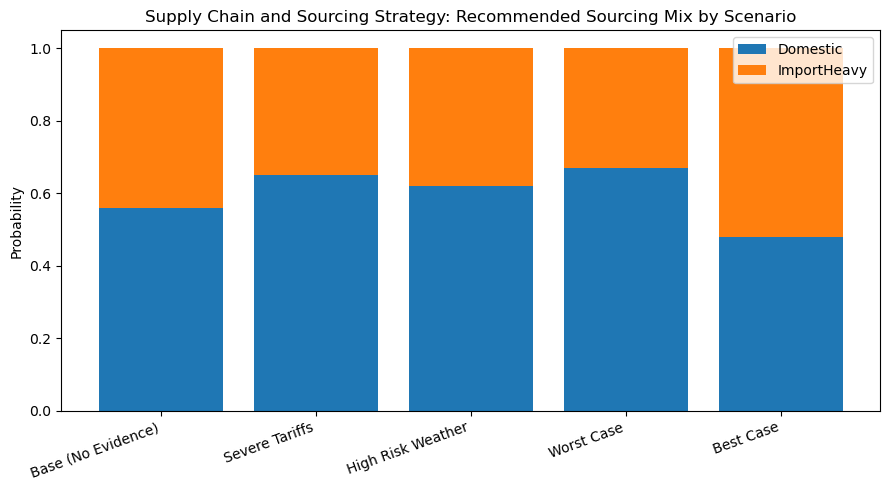

In [8]:
#4: Run Everything and Charts
if __name__ == "__main__":

#Bayes rule demo
    run_bayes_demo()

#Build BN and run scenarios
    bn_model = build_bn()
    scenario_results = run_scenarios(bn_model)

#Convert to DataFrame
    df = pd.DataFrame(scenario_results)
    csv_path = "scenario_results.csv" #(rounded decimals in CSV for better formatting)
    df.to_csv(csv_path, index=False)
    print(f"\nCSV exported to: {csv_path}")
    df.head()
    df.columns

#Chart 1 Stability vs HighRisk
plt.figure(figsize=(9, 5))
x = range(len(df))
plt.bar(x, df["Stable"], label="Stable")
plt.bar(x, df["HighRisk"], bottom=df["Stable"], label="HighRisk")
plt.xticks(x, df["Scenario"], rotation=20, ha="right")
plt.ylabel("Probability")
plt.title("Supply Chain and Sourcing Strategy: Business Stability by Scenario")
plt.legend()
plt.tight_layout()
plt.show()

#Chart 2 Sourcing Strategy
plt.figure(figsize=(9, 5))
plt.bar(x, df["Domestic"], label="Domestic")
plt.bar(x, df["ImportHeavy"], bottom=df["Domestic"], label="ImportHeavy")
plt.xticks(x, df["Scenario"], rotation=20, ha="right")
plt.ylabel("Probability")
plt.title("Supply Chain and Sourcing Strategy: Recommended Sourcing Mix by Scenario")
plt.legend()
plt.tight_layout()
plt.show()

4. Leaders can use this model for forecasting, hedging, sourcing decisions, and risk communication. The Bayesian framework offers transparent, explainable AI logic that aligns with digital transformation initiatives and enhances data-driven executive decision-making.
